# A Statistical Analysis of Vowel Inventories of World Languages
**Based on:** Wisniewski (2025) — Université Paris Cité Lab
**Dataset:** PHOIBLE 2.0

---
### Table of Contents
- **Section 2** — Getting Started with PHOIBLE (Q1–Q3)
- **Section 3** — Testing Linguistic Universals (Q4–Q10)
- **Section 4** — Discovering Regularities / Association Rules (Q11–Q20)

## Setup & Data Loading

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scipy mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')



In [2]:
# ── Load PHOIBLE ──────────────────────────────────────────────────────────────
PHOIBLE_URL = 'https://raw.githubusercontent.com/phoible/dev/master/data/phoible.csv'

try:
    df = pd.read_csv(PHOIBLE_URL, low_memory=False)
    print(f' Downloaded — {df.shape[0]:,} rows, {df.shape[1]} columns')
except:
    df = pd.read_csv('phoible.csv', low_memory=False)
    print(f' Local load — {df.shape[0]:,} rows')

# Keep only VOWELS for this lab
vowels_df = df[df['SegmentClass'] == 'vowel'].copy()
print(f'Vowel rows : {len(vowels_df):,}')
print(f'Columns    : {df.columns.tolist()}')

 Downloaded — 105,484 rows, 49 columns
Vowel rows : 31,052
Columns    : ['InventoryID', 'Glottocode', 'ISO6393', 'LanguageName', 'SpecificDialect', 'GlyphID', 'Phoneme', 'Allophones', 'Marginal', 'SegmentClass', 'Source', 'tone', 'stress', 'syllabic', 'short', 'long', 'consonantal', 'sonorant', 'continuant', 'delayedRelease', 'approximant', 'tap', 'trill', 'nasal', 'lateral', 'labial', 'round', 'labiodental', 'coronal', 'anterior', 'distributed', 'strident', 'dorsal', 'high', 'low', 'front', 'back', 'tense', 'retractedTongueRoot', 'advancedTongueRoot', 'periodicGlottalSource', 'epilaryngealSource', 'spreadGlottis', 'constrictedGlottis', 'fortis', 'lenis', 'raisedLarynxEjective', 'loweredLarynxImplosive', 'click']


---
## Section 2 — Getting Started with PHOIBLE
### Q1. Number of languages, average vowels per language, distribution of vowel inventory sizes

         Q1 — PHOIBLE BASIC STATISTICS
Total languages in PHOIBLE   : 2,716
Average vowels per language  : 10.54
Median vowels per language   : 9.0

--- Distribution Summary ---
count    2716.00
mean       10.54
std         6.93
min         2.00
25%         6.00
50%         9.00
75%        13.00
max        72.00
Name: Vowel_Count, dtype: float64


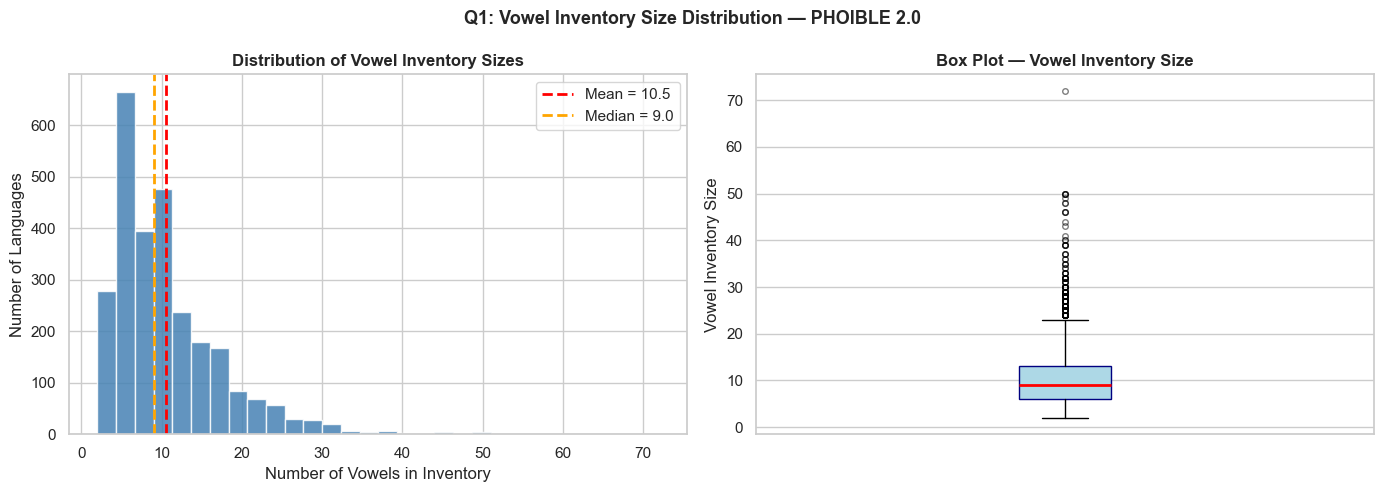

In [3]:
# ── Q1: Basic statistics ──────────────────────────────────────────────────────

# Vowel inventory size per language
vowel_inventory = (
    vowels_df.groupby('LanguageName')['Phoneme']
    .nunique()
    .reset_index()
)
vowel_inventory.columns = ['Language', 'Vowel_Count']

n_languages  = vowel_inventory['Language'].nunique()
avg_vowels   = vowel_inventory['Vowel_Count'].mean()
median_vowels = vowel_inventory['Vowel_Count'].median()


print('         Q1 — PHOIBLE BASIC STATISTICS')

print(f'Total languages in PHOIBLE   : {n_languages:,}')
print(f'Average vowels per language  : {avg_vowels:.2f}')
print(f'Median vowels per language   : {median_vowels:.1f}')
print()
print('--- Distribution Summary ---')
print(vowel_inventory['Vowel_Count'].describe().round(2))

# ── Plot: Distribution of vowel inventory sizes ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(vowel_inventory['Vowel_Count'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(avg_vowels, color='red', linestyle='--', linewidth=2,
                label=f'Mean = {avg_vowels:.1f}')
axes[0].axvline(median_vowels, color='orange', linestyle='--', linewidth=2,
                label=f'Median = {median_vowels:.1f}')
axes[0].set_xlabel('Number of Vowels in Inventory')
axes[0].set_ylabel('Number of Languages')
axes[0].set_title('Distribution of Vowel Inventory Sizes', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(vowel_inventory['Vowel_Count'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1].set_ylabel('Vowel Inventory Size')
axes[1].set_title('Box Plot — Vowel Inventory Size', fontweight='bold')
axes[1].set_xticks([])

plt.suptitle('Q1: Vowel Inventory Size Distribution — PHOIBLE 2.0',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_vowel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2. Why is it interesting to examine these statistics?

In [4]:

skewness = vowel_inventory['Vowel_Count'].skew()
print(f'Skewness of distribution : {skewness:.3f}')
if skewness > 0:
    print('→ Right-skewed: most languages have fewer vowels,'
          ' few languages have very large inventories')
else:
    print('→ Left-skewed: most languages have more vowels')

Skewness of distribution : 2.022
→ Right-skewed: most languages have fewer vowels, few languages have very large inventories


### Q3. Outlier Detection using IQR Method

Q3 — IQR OUTLIER DETECTION
Q1 (25th percentile) : 6.0
Q3 (75th percentile) : 13.0
IQR                  : 7.0
Lower bound          : -4.5
Upper bound          : 23.5

Upper outliers (> 23.5) : 153 languages
       Language  Vowel_Count
          Dutch           72
 Northern Qiang           50
      Elfdalian           50
         Danish           50
             So           50
Scottish Gaelic           49
            Dan           48
        Bengali           48
            !XU           46
        Chechen           46
        Spanish           46
         Korean           44
         PARAUK           43
       Gujarati           41
         Breton           40

Lower outliers (< -4.5) : 0 languages
Empty DataFrame
Columns: [Language, Vowel_Count]
Index: []


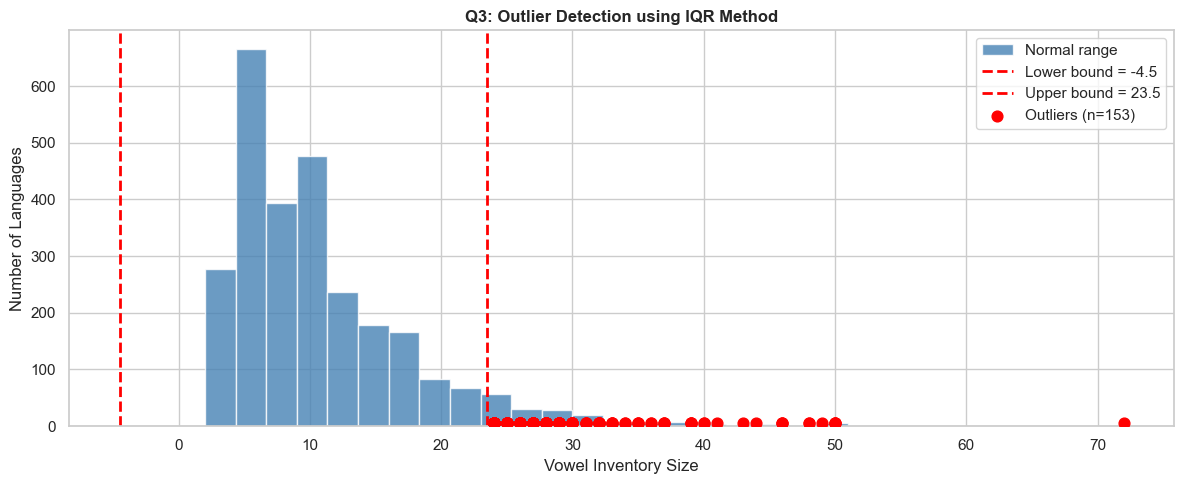

In [5]:
# ── Q3: IQR Outlier Detection ─────────────────────────────────────────────────
Q1_val = vowel_inventory['Vowel_Count'].quantile(0.25)
Q3_val = vowel_inventory['Vowel_Count'].quantile(0.75)
IQR    = Q3_val - Q1_val

lower_bound = Q1_val - 1.5 * IQR
upper_bound = Q3_val + 1.5 * IQR

outliers_high = vowel_inventory[vowel_inventory['Vowel_Count'] > upper_bound]
outliers_low  = vowel_inventory[vowel_inventory['Vowel_Count'] < lower_bound]

print('Q3 — IQR OUTLIER DETECTION')

print(f'Q1 (25th percentile) : {Q1_val}')
print(f'Q3 (75th percentile) : {Q3_val}')
print(f'IQR                  : {IQR}')
print(f'Lower bound          : {lower_bound}')
print(f'Upper bound          : {upper_bound}')
print()
print(f'Upper outliers (> {upper_bound}) : {len(outliers_high)} languages')
print(outliers_high.sort_values('Vowel_Count', ascending=False).head(15).to_string(index=False))
print()
print(f'Lower outliers (< {lower_bound}) : {len(outliers_low)} languages')
print(outliers_low.sort_values('Vowel_Count').head(10).to_string(index=False))

# ── Visualize outliers ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(vowel_inventory['Vowel_Count'], bins=30,
        color='steelblue', edgecolor='white', alpha=0.8, label='Normal range')
ax.axvline(lower_bound, color='red', linestyle='--', linewidth=2,
           label=f'Lower bound = {lower_bound:.1f}')
ax.axvline(upper_bound, color='red', linestyle='--', linewidth=2,
           label=f'Upper bound = {upper_bound:.1f}')

# Mark outliers
outlier_counts = outliers_high['Vowel_Count'].values
ax.scatter(outlier_counts,
           [5] * len(outlier_counts),
           color='red', zorder=5, s=60, label=f'Outliers (n={len(outliers_high)})')

ax.set_xlabel('Vowel Inventory Size')
ax.set_ylabel('Number of Languages')
ax.set_title('Q3: Outlier Detection using IQR Method', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q3_outliers.png', dpi=150, bbox_inches='tight')
plt.show()



---
## Section 3 — Testing Linguistic Universals
### Q4. Three most frequent vowels

Q4 — TOP 20 MOST FREQUENT VOWELS
Phoneme  Lang_Count  Percentage
      i        2534       93.30
      a        2427       89.36
      u        2409       88.70
      e        1694       62.37
      o        1658       61.05
      ɛ        1019       37.52
      ɔ         963       35.46
     iː         871       32.07
     aː         825       30.38
     uː         806       29.68
      ə         620       22.83
     eː         585       21.54
     oː         572       21.06
     ĩ         511       18.81
     ã         497       18.30
     ũ         471       17.34
      ɨ         468       17.23
      ɪ         406       14.95
      ʊ         382       14.06
     õ         335       12.33


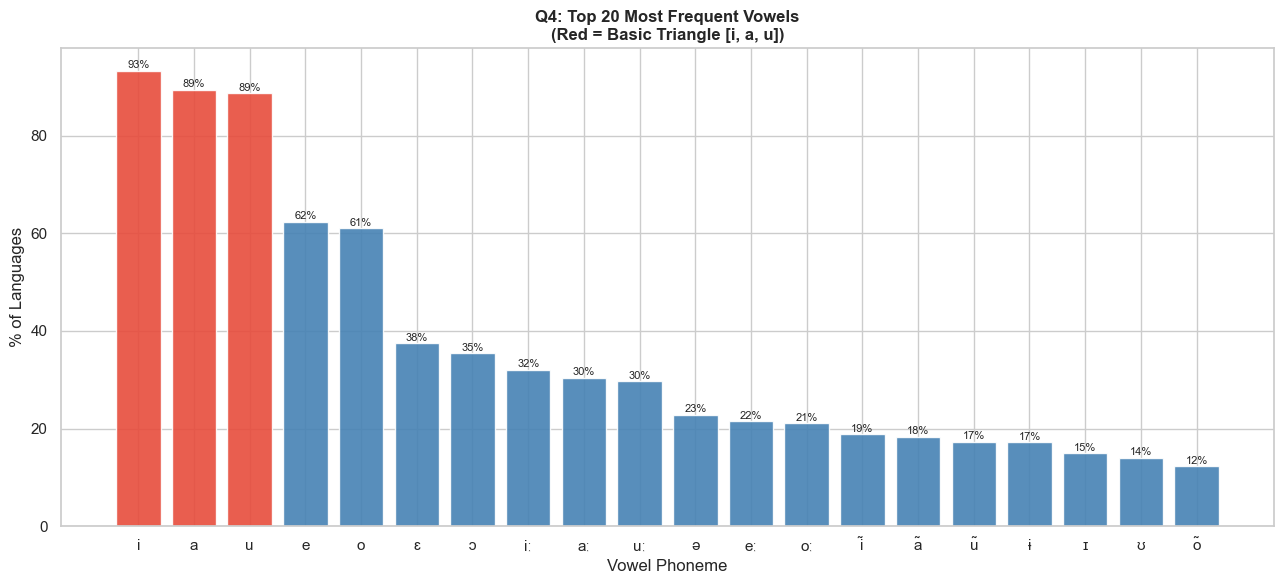


Top 3 most frequent vowels:
  #1: [i] — 93.3% of languages
  #2: [a] — 89.36% of languages
  #3: [u] — 88.7% of languages


In [6]:
# ── Q4: Most frequent vowels ──────────────────────────────────────────────────
total_languages = vowel_inventory['Language'].nunique()

vowel_freq = (
    vowels_df.groupby('Phoneme')['LanguageName']
    .nunique()
    .reset_index()
)
vowel_freq.columns = ['Phoneme', 'Lang_Count']
vowel_freq['Percentage'] = (vowel_freq['Lang_Count'] / total_languages * 100).round(2)
vowel_freq = vowel_freq.sort_values('Percentage', ascending=False).reset_index(drop=True)

print('Q4 — TOP 20 MOST FREQUENT VOWELS')
print('=' * 45)
print(vowel_freq.head(20).to_string(index=False))

# Plot top 20
top20 = vowel_freq.head(20)
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#e74c3c' if p in ['i','a','u'] else 'steelblue'
          for p in top20['Phoneme']]
bars = ax.bar(top20['Phoneme'], top20['Percentage'],
              color=colors, edgecolor='white', alpha=0.9)
ax.set_xlabel('Vowel Phoneme')
ax.set_ylabel('% of Languages')
ax.set_title('Q4: Top 20 Most Frequent Vowels\n(Red = Basic Triangle [i, a, u])',
             fontweight='bold')
for bar, val in zip(bars, top20['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('q4_frequent_vowels.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 3 most frequent vowels:')
for i, row in vowel_freq.head(3).iterrows():
    print(f'  #{i+1}: [{row["Phoneme"]}] — {row["Percentage"]}% of languages')

### Q5. Proportion of languages containing [i], [a], [u] — Testing the Universal Triangle

Q5 — BASIC VOWEL TRIANGLE UNIVERSALITY TEST
  [i] : 2,534 languages (93.3%)
  [a] : 2,427 languages (89.4%)
  [u] : 2,409 languages (88.7%)

  Languages with ALL THREE [i, a, u]: 2,161 (79.6%)
  Languages with AT LEAST ONE       : 2,673 (98.4%)


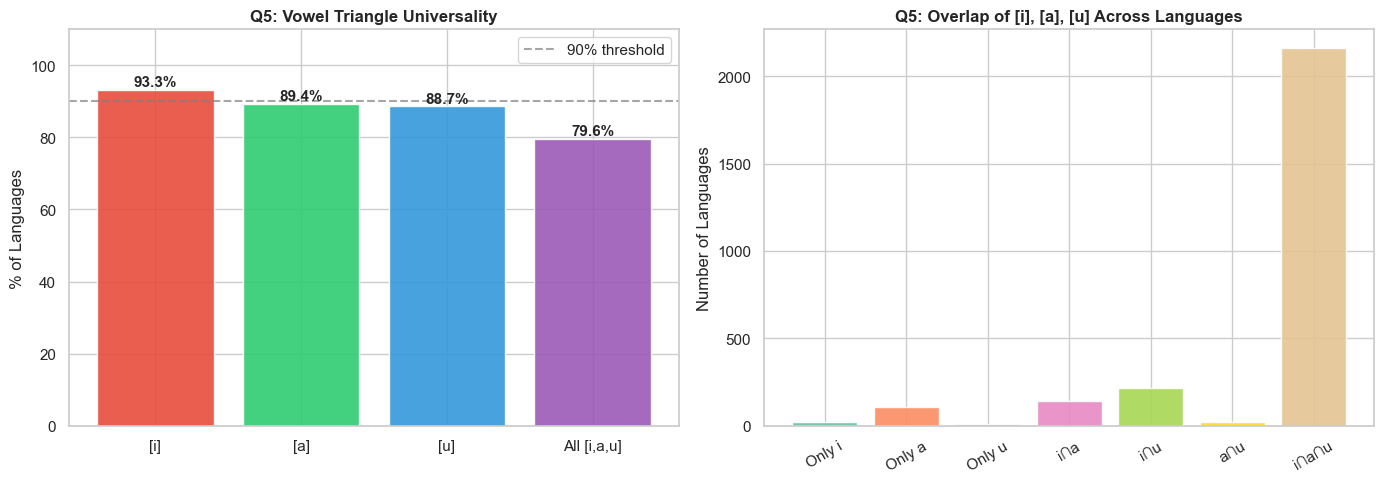

In [7]:
# ── Q5: Vowel Triangle Universal ─────────────────────────────────────────────
triangle = ['i', 'a', 'u']

print('Q5 — BASIC VOWEL TRIANGLE UNIVERSALITY TEST')
print('=' * 55)

results = {}
for v in triangle:
    count = vowels_df[vowels_df['Phoneme'] == v]['LanguageName'].nunique()
    pct   = count / total_languages * 100
    results[v] = {'count': count, 'pct': pct}
    print(f'  [{v}] : {count:,} languages ({pct:.1f}%)')

# Languages with ALL THREE
langs_with_i = set(vowels_df[vowels_df['Phoneme'] == 'i']['LanguageName'])
langs_with_a = set(vowels_df[vowels_df['Phoneme'] == 'a']['LanguageName'])
langs_with_u = set(vowels_df[vowels_df['Phoneme'] == 'u']['LanguageName'])

all_three   = langs_with_i & langs_with_a & langs_with_u
pct_all3    = len(all_three) / total_languages * 100

print(f'\n  Languages with ALL THREE [i, a, u]: {len(all_three):,} ({pct_all3:.1f}%)')

# Languages with at least one
at_least_one = langs_with_i | langs_with_a | langs_with_u
print(f'  Languages with AT LEAST ONE       : {len(at_least_one):,} ({len(at_least_one)/total_languages*100:.1f}%)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
labels = ['[i]', '[a]', '[u]', 'All [i,a,u]']
values = [results['i']['pct'], results['a']['pct'],
          results['u']['pct'], pct_all3]
bar_colors = ['#e74c3c','#2ecc71','#3498db','#9b59b6']
bars = axes[0].bar(labels, values, color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].axhline(90, color='gray', linestyle='--', alpha=0.7, label='90% threshold')
axes[0].set_ylabel('% of Languages')
axes[0].set_ylim(0, 110)
axes[0].set_title('Q5: Vowel Triangle Universality', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Venn-style overlap (manual)
only_i   = len(langs_with_i - langs_with_a - langs_with_u)
only_a   = len(langs_with_a - langs_with_i - langs_with_u)
only_u   = len(langs_with_u - langs_with_i - langs_with_a)
i_and_a  = len((langs_with_i & langs_with_a) - langs_with_u)
i_and_u  = len((langs_with_i & langs_with_u) - langs_with_a)
a_and_u  = len((langs_with_a & langs_with_u) - langs_with_i)
all_3    = len(all_three)

overlap_labels = ['Only i','Only a','Only u','i∩a','i∩u','a∩u','i∩a∩u']
overlap_values = [only_i, only_a, only_u, i_and_a, i_and_u, a_and_u, all_3]
axes[1].bar(overlap_labels, overlap_values,
            color=sns.color_palette('Set2', 7), edgecolor='white', alpha=0.9)
axes[1].set_ylabel('Number of Languages')
axes[1].set_title('Q5: Overlap of [i], [a], [u] Across Languages', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('q5_vowel_triangle.png', dpi=150, bbox_inches='tight')
plt.show()



### Q6–Q9. Chi-square Test & Mutual Information for Phoneme Pairs

In [8]:
# ── Q6: Build 2x2 contingency table for any phoneme pair ─────────────────────
# ── Q7: Chi-square test ───────────────────────────────────────────────────────
# ── Q8: Mutual Information ────────────────────────────────────────────────────

def analyze_phoneme_pair(phoneme_A, phoneme_B, vowels_df, total_languages):
    """
    For a pair (A, B):
    - Build 2x2 contingency table
    - Compute Chi-square test
    - Compute Mutual Information
    """
    langs_A = set(vowels_df[vowels_df['Phoneme'] == phoneme_A]['LanguageName'])
    langs_B = set(vowels_df[vowels_df['Phoneme'] == phoneme_B]['LanguageName'])
    all_langs = set(vowels_df['LanguageName'].unique())

    # 2x2 table counts
    AB   = len(langs_A & langs_B)               # A=1, B=1
    A_nB = len(langs_A - langs_B)               # A=1, B=0
    nA_B = len(langs_B - langs_A)               # A=0, B=1
    nAnB = len(all_langs - langs_A - langs_B)   # A=0, B=0
    N    = total_languages

    # Contingency table
    table = np.array([[AB, A_nB],
                      [nA_B, nAnB]])

    print(f'\n{'='*55}')
    print(f'  PHONEME PAIR: [{phoneme_A}] vs [{phoneme_B}]')
    print(f'{'='*55}')
    print(f'\n  2x2 CONTINGENCY TABLE:')
    print(f'  {"":12} | B present | B absent')
    print(f'  {"A present":12} | {AB:9} | {A_nB:8}')
    print(f'  {"A absent":12} | {nA_B:9} | {nAnB:8}')

    # ── Q7: Chi-square test ───────────────────────────────────────────────────
    chi2, p_value, dof, expected = chi2_contingency(table)
    print(f'\n  Q7 — CHI-SQUARE TEST:')
    print(f'    chi2 statistic : {chi2:.4f}')
    print(f'    p-value        : {p_value:.6f}')
    print(f'    Degrees of freedom: {dof}')
    if p_value < 0.05:
        print(f'    → SIGNIFICANT association (p < 0.05)')
        print(f'    → [{phoneme_A}] and [{phoneme_B}] do NOT occur independently')
    else:
        print(f'    → No significant association (p >= 0.05)')
        print(f'    → [{phoneme_A}] and [{phoneme_B}] occur independently')

    # ── Q8: Mutual Information ────────────────────────────────────────────────
    # Joint and marginal probabilities
    p = {}
    p[(1,1)] = AB   / N
    p[(1,0)] = A_nB / N
    p[(0,1)] = nA_B / N
    p[(0,0)] = nAnB / N

    pA = {1: (AB + A_nB) / N, 0: (nA_B + nAnB) / N}
    pB = {1: (AB + nA_B) / N, 0: (A_nB + nAnB) / N}

    MI = 0.0
    for a in [0, 1]:
        for b in [0, 1]:
            if p[(a,b)] > 0:
                MI += p[(a,b)] * np.log2(p[(a,b)] / (pA[a] * pB[b]))

    print(f'\n  Q8 — MUTUAL INFORMATION:')
    print(f'    MI = {MI:.6f} bits')
    if MI > 0.01:
        print(f'    → Positive association: [{phoneme_A}] and [{phoneme_B}] co-occur MORE than chance')
    elif MI < -0.01:
        print(f'    → Negative: mutual exclusion tendency')
    else:
        print(f'    → Near zero: approximately independent')

    # ── Q9: Compare chi2 vs MI ────────────────────────────────────────────────
    print(f'\n  Q9 — COMPARISON: Chi² vs Mutual Information:')
    print(f'    Chi²: {"Significant" if p_value < 0.05 else "Not significant"}')
    print(f'    MI  : {"Positive (co-occurrence)" if MI > 0.01 else "Near zero (independence)"}')
    print(f'    → Both methods: {"AGREE" if (p_value < 0.05) == (MI > 0.01) else "DISAGREE"}')

    return {'chi2': chi2, 'p_value': p_value, 'MI': MI, 'table': table}


# ── Test on key pairs ─────────────────────────────────────────────────────────
print('Q6–Q9: PHONEME PAIR ANALYSIS')

pairs_to_test = [('i', 'u'), ('i', 'a'), ('a', 'u'), ('i', 'e'), ('a', 'o')]
pair_results  = {}

for A, B in pairs_to_test:
    pair_results[(A, B)] = analyze_phoneme_pair(A, B, vowels_df, total_languages)

Q6–Q9: PHONEME PAIR ANALYSIS

  PHONEME PAIR: [i] vs [u]

  2x2 CONTINGENCY TABLE:
               | B present | B absent
  A present    |      2378 |      156
  A absent     |        31 |      151

  Q7 — CHI-SQUARE TEST:
    chi2 statistic : 991.6092
    p-value        : 0.000000
    Degrees of freedom: 1
    → SIGNIFICANT association (p < 0.05)
    → [i] and [u] do NOT occur independently

  Q8 — MUTUAL INFORMATION:
    MI = 0.153615 bits
    → Positive association: [i] and [u] co-occur MORE than chance

  Q9 — COMPARISON: Chi² vs Mutual Information:
    Chi²: Significant
    MI  : Positive (co-occurrence)
    → Both methods: AGREE

  PHONEME PAIR: [i] vs [a]

  2x2 CONTINGENCY TABLE:
               | B present | B absent
  A present    |      2299 |      235
  A absent     |       128 |       54

  Q7 — CHI-SQUARE TEST:
    chi2 statistic : 72.1637
    p-value        : 0.000000
    Degrees of freedom: 1
    → SIGNIFICANT association (p < 0.05)
    → [i] and [a] do NOT occur independ

### Q10. Conclusions on Universals

Q10 — CONCLUSIONS

Summary of Pair Analysis:
Pair       | Chi2       | p-value      | MI         | Significant?
-----------------------------------------------------------------
[i]+[u]   |     991.61 |     0.000000 |   0.153615 |  Yes
[i]+[a]   |      72.16 |     0.000000 |   0.014508 |  Yes
[a]+[u]   |      29.92 |     0.000000 |   0.006954 |  Yes
[i]+[e]   |     152.72 |     0.000000 |   0.040553 |  Yes
[a]+[o]   |      32.86 |     0.000000 |   0.008688 |  Yes


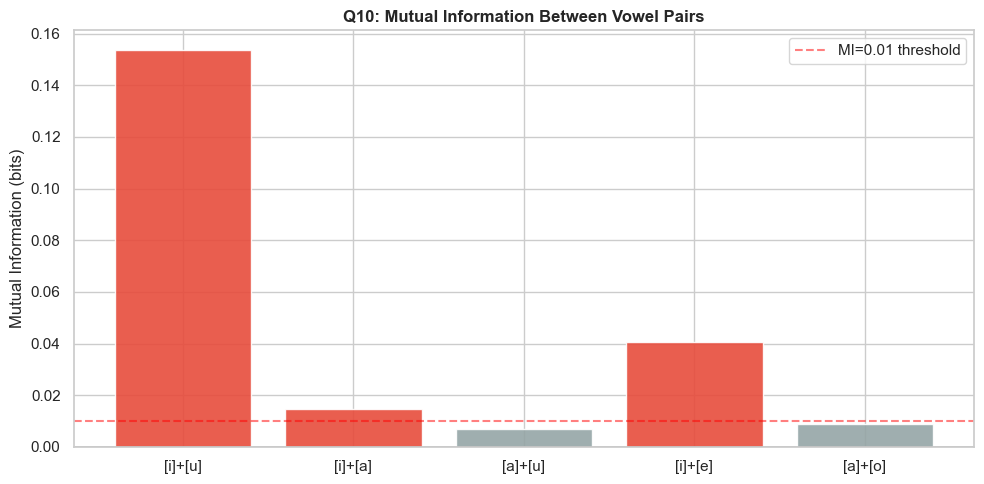

In [9]:
# ── Q10: Summary conclusions ──────────────────────────────────────────────────
print('Q10 — CONCLUSIONS')


# Summary table of all pairs
print('\nSummary of Pair Analysis:')
print(f'{"Pair":10} | {"Chi2":10} | {"p-value":12} | {"MI":10} | Significant?')
print('-' * 65)
for (A, B), res in pair_results.items():
    sig = ' Yes' if res['p_value'] < 0.05 else ' No'
    print(f'[{A}]+[{B}]   | {res["chi2"]:10.2f} | {res["p_value"]:12.6f} | {res["MI"]:10.6f} | {sig}')

# Visualize MI values
fig, ax = plt.subplots(figsize=(10, 5))
pair_labels = [f'[{A}]+[{B}]' for A, B in pair_results.keys()]
mi_values   = [res['MI'] for res in pair_results.values()]
colors = ['#e74c3c' if mi > 0.01 else '#95a5a6' for mi in mi_values]
ax.bar(pair_labels, mi_values, color=colors, edgecolor='white', alpha=0.9)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(0.01, color='red', linestyle='--', alpha=0.5, label='MI=0.01 threshold')
ax.set_ylabel('Mutual Information (bits)')
ax.set_title('Q10: Mutual Information Between Vowel Pairs', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q10_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()



---
## Section 4 — Discovering Regularities: Association Rules
### Q11–Q13. Support for Single Phonemes and Pairs

Q11 — SUPPORT FOR SIZE-1 ITEMSETS (Individual Vowels)
Phoneme  Lang_Count  Support
      i        2534 0.932990
      a        2427 0.893594
      u        2409 0.886966
      e        1694 0.623711
      o        1658 0.610457
      ɛ        1019 0.375184
      ɔ         963 0.354566
     iː         871 0.320692
     aː         825 0.303756
     uː         806 0.296760
      ə         620 0.228277
     eː         585 0.215390
     oː         572 0.210604
     ĩ         511 0.188144
     ã         497 0.182990
     ũ         471 0.173417
      ɨ         468 0.172312
      ɪ         406 0.149485
      ʊ         382 0.140648
     õ         335 0.123343


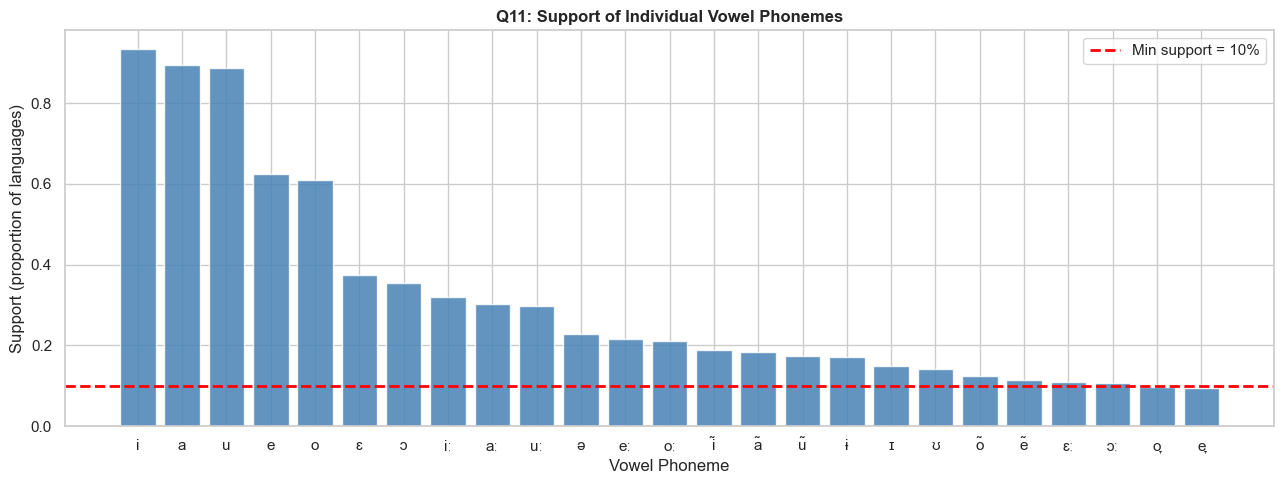

In [10]:
# ── Q11: Support for single phonemes (size-1 itemsets) ───────────────────────
print('Q11 — SUPPORT FOR SIZE-1 ITEMSETS (Individual Vowels)')


support_1 = vowel_freq.copy()
support_1['Support'] = support_1['Lang_Count'] / total_languages
support_1 = support_1[['Phoneme', 'Lang_Count', 'Support']].sort_values('Support', ascending=False)

print(support_1.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
top_vowels = support_1.head(25)
ax.bar(top_vowels['Phoneme'], top_vowels['Support'],
       color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(0.10, color='red', linestyle='--', linewidth=2,
           label='Min support = 10%')
ax.set_xlabel('Vowel Phoneme')
ax.set_ylabel('Support (proportion of languages)')
ax.set_title('Q11: Support of Individual Vowel Phonemes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q11_support_single.png', dpi=150, bbox_inches='tight')
plt.show()

Q12–Q13: FREQUENT ITEMSETS OF SIZE 2
Minimum support threshold: 10%
Vowels above 10% support: ['i', 'a', 'u', 'e', 'o', 'ɛ', 'ɔ', 'iː', 'aː', 'uː', 'ə', 'eː', 'oː', 'ĩ', 'ã', 'ũ', 'ɨ', 'ɪ', 'ʊ', 'õ']

Frequent itemsets of size 2 (support >= 10%): 119
Phoneme_A Phoneme_B  Count  Support
        i         u   2378 0.875552
        i         a   2299 0.846465
        a         u   2181 0.803019
        i         e   1659 0.610825
        i         o   1619 0.596097
        u         e   1588 0.584683
        a         e   1564 0.575847
        u         o   1537 0.565906
        e         o   1537 0.565906
        a         o   1527 0.562224
        i         ɛ    943 0.347202
        u         ɛ    915 0.336892
        a         ɛ    904 0.332842
        i         ɔ    902 0.332106
        u         ɔ    893 0.328792
        a         ɔ    880 0.324006
        ɛ         ɔ    829 0.305228
        a        aː    799 0.294183
        i        iː    798 0.293814
       iː        uː    79

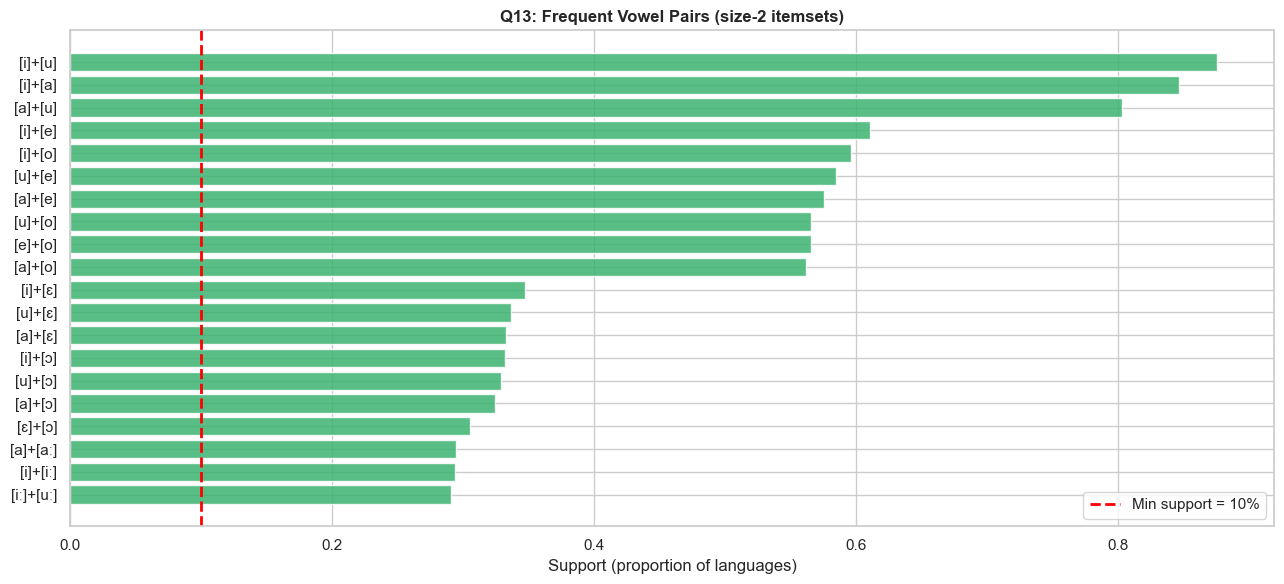

In [11]:
# ── Q12–Q13: Support for size-2 itemsets (pairs) ─────────────────────────────
MIN_SUPPORT = 0.10  # 10%

print('Q12–Q13: FREQUENT ITEMSETS OF SIZE 2')
print(f'Minimum support threshold: {MIN_SUPPORT*100:.0f}%')
print('=' * 55)

# Get vowels with support > MIN_SUPPORT (to reduce computation)
frequent_vowels = support_1[support_1['Support'] >= MIN_SUPPORT]['Phoneme'].tolist()
print(f'Vowels above {MIN_SUPPORT*100:.0f}% support: {frequent_vowels[:20]}')

# Compute pairwise support
pair_supports = []
all_langs_set = set(vowels_df['LanguageName'].unique())

# lang → set of vowels mapping (faster lookup)
lang_vowels = vowels_df.groupby('LanguageName')['Phoneme'].apply(set).to_dict()

from itertools import combinations
for A, B in combinations(frequent_vowels[:30], 2):  # top 30 vowels
    count_AB = sum(1 for lang, vows in lang_vowels.items() if A in vows and B in vows)
    support  = count_AB / total_languages
    if support >= MIN_SUPPORT:
        pair_supports.append({'Phoneme_A': A, 'Phoneme_B': B,
                              'Count': count_AB, 'Support': support})

pair_df = pd.DataFrame(pair_supports).sort_values('Support', ascending=False).reset_index(drop=True)

print(f'\nFrequent itemsets of size 2 (support >= {MIN_SUPPORT*100:.0f}%): {len(pair_df)}')
print(pair_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
top_pairs = pair_df.head(20)
pair_labels = [f'[{row.Phoneme_A}]+[{row.Phoneme_B}]' for _, row in top_pairs.iterrows()]
ax.barh(pair_labels[::-1], top_pairs['Support'][::-1],
        color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.axvline(MIN_SUPPORT, color='red', linestyle='--', linewidth=2,
           label=f'Min support = {MIN_SUPPORT*100:.0f}%')
ax.set_xlabel('Support (proportion of languages)')
ax.set_title('Q13: Frequent Vowel Pairs (size-2 itemsets)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q13_frequent_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

### Q14. Comment on Regularities in Frequent Pairs

In [12]:
# ── Q14: Regularities in frequent pairs ──────────────────────────────────────
print('Q14 — REGULARITIES IN FREQUENT ITEMSETS')
print('=' * 55)
print()
print('Top 10 frequent vowel pairs:')
print(pair_df[['Phoneme_A','Phoneme_B','Support']].head(10).to_string(index=False))

# Check if basic triangle pairs dominate
triangle_pairs = [('i','a'), ('i','u'), ('a','u')]
print('\nBasic triangle pairs support:')
for A, B in triangle_pairs:
    row = pair_df[(pair_df['Phoneme_A']==A) & (pair_df['Phoneme_B']==B)]
    if len(row) == 0:
        row = pair_df[(pair_df['Phoneme_A']==B) & (pair_df['Phoneme_B']==A)]
    if len(row) > 0:
        print(f'  [{A}]+[{B}]: support = {row.iloc[0]["Support"]:.3f} ({row.iloc[0]["Support"]*100:.1f}%)')



Q14 — REGULARITIES IN FREQUENT ITEMSETS

Top 10 frequent vowel pairs:
Phoneme_A Phoneme_B  Support
        i         u 0.875552
        i         a 0.846465
        a         u 0.803019
        i         e 0.610825
        i         o 0.596097
        u         e 0.584683
        a         e 0.575847
        u         o 0.565906
        e         o 0.565906
        a         o 0.562224

Basic triangle pairs support:
  [i]+[a]: support = 0.846 (84.6%)
  [i]+[u]: support = 0.876 (87.6%)
  [a]+[u]: support = 0.803 (80.3%)


### Q15–Q16. Confidence & Lift for Association Rules

Q15 — CONFIDENCE & LIFT FOR ASSOCIATION RULES
     Rule  Support(A)  Support(B)  Support(AB)  Confidence   Lift
[e] → [o]      0.6237      0.6105       0.5659      0.9073 1.4863
[i] → [u]      0.9330      0.8870       0.8756      0.9384 1.0580
[u] → [i]      0.8870      0.9330       0.8756      0.9871 1.0580
[i] → [e]      0.9330      0.6237       0.6108      0.6547 1.0497
[u] → [o]      0.8870      0.6105       0.5659      0.6380 1.0452
[a] → [e]      0.8936      0.6237       0.5758      0.6444 1.0332
[a] → [i]      0.8936      0.9330       0.8465      0.9473 1.0153
[i] → [a]      0.9330      0.8936       0.8465      0.9073 1.0153


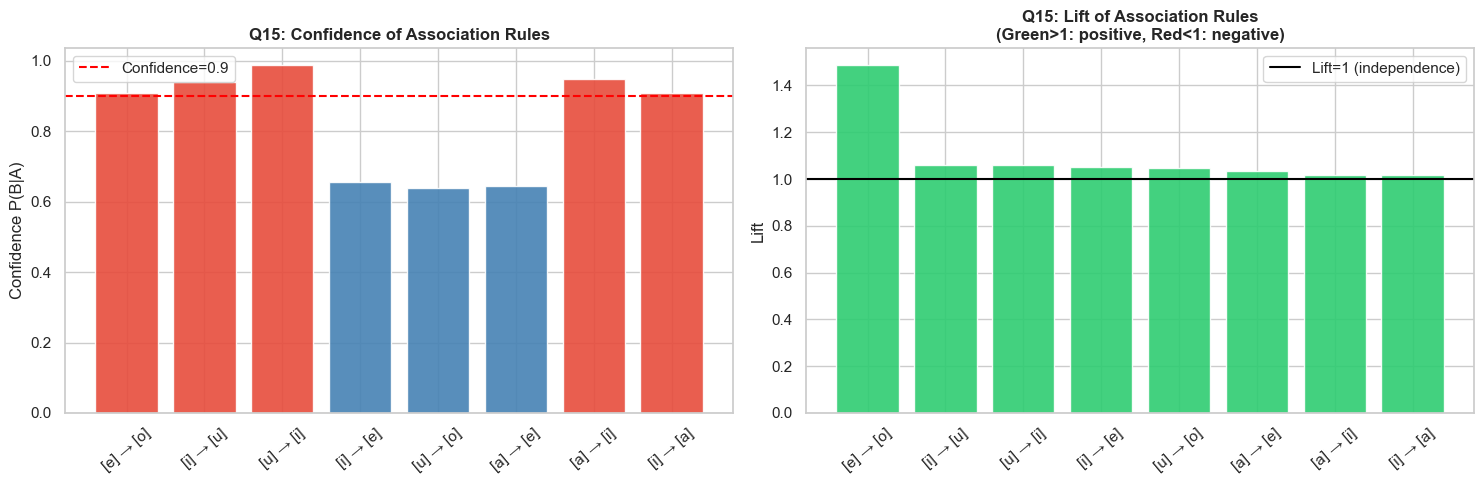

In [13]:
# ── Q15: Confidence & Lift ────────────────────────────────────────────────────
def compute_confidence_lift(A, B, lang_vowels, total_languages, support_dict):
    """
    Compute support(A∪B), confidence(A→B), lift(A→B)
    """
    count_A  = sum(1 for vows in lang_vowels.values() if A in vows)
    count_B  = sum(1 for vows in lang_vowels.values() if B in vows)
    count_AB = sum(1 for vows in lang_vowels.values() if A in vows and B in vows)

    support_A  = count_A  / total_languages
    support_B  = count_B  / total_languages
    support_AB = count_AB / total_languages

    confidence = support_AB / support_A if support_A > 0 else 0
    lift       = confidence / support_B if support_B > 0 else 0

    return {
        'Rule': f'[{A}] → [{B}]',
        'Support(A)' : round(support_A, 4),
        'Support(B)' : round(support_B, 4),
        'Support(AB)': round(support_AB, 4),
        'Confidence' : round(confidence, 4),
        'Lift'       : round(lift, 4)
    }

print('Q15 — CONFIDENCE & LIFT FOR ASSOCIATION RULES')
print('=' * 60)

rules_to_check = [
    ('i', 'u'), ('i', 'a'), ('u', 'i'), ('a', 'i'),
    ('i', 'e'), ('u', 'o'), ('a', 'e'), ('e', 'o')
]

rule_results = []
for A, B in rules_to_check:
    res = compute_confidence_lift(A, B, lang_vowels, total_languages, support_1)
    rule_results.append(res)

rules_df = pd.DataFrame(rule_results).sort_values('Lift', ascending=False)
print(rules_df.to_string(index=False))

# Plot confidence and lift
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confidence
colors_c = ['#e74c3c' if c >= 0.9 else 'steelblue' for c in rules_df['Confidence']]
axes[0].bar(rules_df['Rule'], rules_df['Confidence'],
            color=colors_c, edgecolor='white', alpha=0.9)
axes[0].axhline(0.9, color='red', linestyle='--', label='Confidence=0.9')
axes[0].set_ylabel('Confidence P(B|A)')
axes[0].set_title('Q15: Confidence of Association Rules', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend()

# Lift
colors_l = ['#2ecc71' if l > 1 else '#e74c3c' for l in rules_df['Lift']]
axes[1].bar(rules_df['Rule'], rules_df['Lift'],
            color=colors_l, edgecolor='white', alpha=0.9)
axes[1].axhline(1.0, color='black', linewidth=1.5, linestyle='-', label='Lift=1 (independence)')
axes[1].set_ylabel('Lift')
axes[1].set_title('Q15: Lift of Association Rules\n(Green>1: positive, Red<1: negative)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend()

plt.tight_layout()
plt.savefig('q15_confidence_lift.png', dpi=150, bbox_inches='tight')
plt.show()



### Q17–Q20. Apriori Algorithm (mlxtend)

In [ ]:
# ── Q17: FIXED Binary Matrix ─────────────────────────────────────────────────
MIN_SUPPORT = 0.10

selected_vowels = support_1[support_1['Support'] >= MIN_SUPPORT]['Phoneme'].tolist()
print(f'Selected vowels: {len(selected_vowels)}')
print(selected_vowels)


df_vowel_filtered = vowels_df[
    vowels_df['Phoneme'].isin(selected_vowels)
].copy()

# (duplicates drop)
df_dedup = df_vowel_filtered[['LanguageName','Phoneme']].drop_duplicates()

# crosstab → presence/absence matrix
binary_matrix = pd.crosstab(
    df_dedup['LanguageName'],
    df_dedup['Phoneme']
).astype(bool)  # mlxtend needs bool dtype

print(f'\n Binary matrix shape: {binary_matrix.shape}')
print(f'   Rows = languages, Cols = vowels')
print(binary_matrix.head(3))

Selected vowels: 23
['i', 'a', 'u', 'e', 'o', 'ɛ', 'ɔ', 'iː', 'aː', 'uː', 'ə', 'eː', 'oː', 'ĩ', 'ã', 'ũ', 'ɨ', 'ɪ', 'ʊ', 'õ', 'ẽ', 'ɛː', 'ɔː']

 Binary matrix shape: (2714, 23)
   Rows = languages, Cols = vowels
Phoneme          a     aː    ã      e     eː     ẽ     i     iː    ĩ  \
LanguageName                                                              
!XU           True   True  True  False  False  False  True   True  True   
!Xóõ        True  False  True   True  False   True  True  False  True   
!Xun          True  False  True   True  False  False  True  False  True   

Phoneme           o  ...     uː    ũ      ɔ     ɔː      ə      ɛ     ɛː  \
LanguageName         ...                                                   
!XU           False  ...   True  True  False  False  False  False  False   
!Xóõ         True  ...  False  True  False  False  False  False  False   
!Xun           True  ...  False  True  False  False  False  False  False   

Phoneme           ɨ      ɪ

In [15]:
# ── Q18–Q19: Apriori ─────────────────────────────────────────────────────────
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    binary_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f'Total frequent itemsets: {len(frequent_itemsets)}')
print('\nBy size:')
print(frequent_itemsets['length'].value_counts().sort_index())

for size in [1, 2, 3]:
    subset = frequent_itemsets[frequent_itemsets['length'] == size]
    print(f'\n--- Size {size} ({len(subset)} itemsets) ---')
    print(subset[['itemsets','support']].head(10).to_string(index=False))

frequent_itemsets.to_csv('frequent_itemsets.csv', index=False)
print('\n Saved: frequent_itemsets.csv')

Total frequent itemsets: 412

By size:
length
1     23
2    119
3    270
Name: count, dtype: int64

--- Size 1 (23 itemsets) ---
itemsets  support
     (i) 0.933677
     (a) 0.894252
     (u) 0.887620
     (e) 0.624171
     (o) 0.610906
     (ɛ) 0.375461
     (ɔ) 0.354827
    (iː) 0.320929
    (aː) 0.303979
    (uː) 0.296979

--- Size 2 (119 itemsets) ---
itemsets  support
  (i, u) 0.876197
  (a, i) 0.847089
  (a, u) 0.803611
  (i, e) 0.611275
  (o, i) 0.596536
  (u, e) 0.585114
  (a, e) 0.576271
  (o, u) 0.566323
  (o, e) 0.566323
  (o, a) 0.562638

--- Size 3 (270 itemsets) ---
 itemsets  support
(a, i, u) 0.796242
(i, u, e) 0.581061
(a, i, e) 0.566323
(o, i, u) 0.561901
(o, i, e) 0.557111
(o, a, i) 0.552321
(a, u, e) 0.542741
(o, u, e) 0.535741
(o, a, e) 0.525792
(o, a, u) 0.522845

 Saved: frequent_itemsets.csv


Total rules found: 938

Top 15 rules by Lift:
antecedents consequents  support  confidence   lift
{'õ', 'e'}      {'ẽ'}   0.1021      0.8935 7.7479
     {'ẽ'} {'õ', 'e'}   0.1021      0.8850 7.7479
{'o', 'ẽ'}      {'õ'}   0.1032      0.9428 7.6378
     {'õ'} {'o', 'ẽ'}   0.1032      0.8358 7.6378
     {'ẽ'} {'o', 'õ'}   0.1032      0.8946 7.3571
{'o', 'õ'}      {'ẽ'}   0.1032      0.8485 7.3571
     {'ẽ'} {'õ', 'i'}   0.1032      0.8946 7.2909
{'õ', 'i'}      {'ẽ'}   0.1032      0.8408 7.2909
{'ẽ', 'i'}      {'õ'}   0.1032      0.8946 7.2473
     {'ẽ'}      {'õ'}   0.1032      0.8946 7.2473
     {'õ'}      {'ẽ'}   0.1032      0.8358 7.2473
     {'õ'} {'ẽ', 'i'}   0.1032      0.8358 7.2473
{'ẽ', 'e'}      {'õ'}   0.1021      0.8935 7.2391
     {'õ'} {'ẽ', 'e'}   0.1021      0.8269 7.2391
{'ĩ', 'e'}      {'ẽ'}   0.1080      0.7094 6.1515


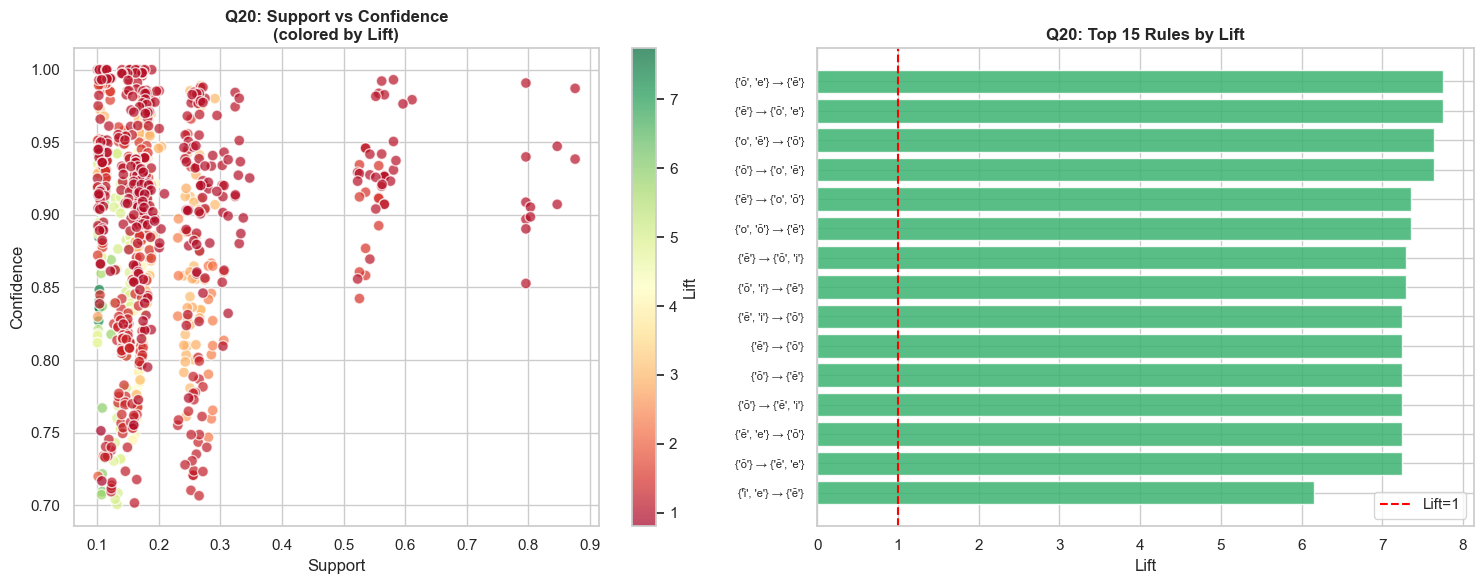

 Saved: association_rules.csv


In [16]:
# ── Q20: Association Rules ────────────────────────────────────────────────────
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.7
)
rules = rules.sort_values('lift', ascending=False)

rules_display = rules[['antecedents','consequents',
                        'support','confidence','lift']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: str(set(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: str(set(x)))

print(f'Total rules found: {len(rules)}')
print('\nTop 15 rules by Lift:')
print(rules_display.head(15).round(4).to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='RdYlGn',
                     alpha=0.7, s=60, edgecolors='white')
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Q20: Support vs Confidence\n(colored by Lift)', fontweight='bold')

top_rules = rules.head(15).reset_index(drop=True)
rule_labels = [
    f'{str(set(r.antecedents))} → {str(set(r.consequents))}'
    for _, r in top_rules.iterrows()
]
axes[1].barh(range(len(top_rules)), top_rules['lift'].values[::-1],
             color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_yticks(range(len(top_rules)))
axes[1].set_yticklabels(rule_labels[::-1], fontsize=8)
axes[1].axvline(1.0, color='red', linestyle='--', label='Lift=1')
axes[1].set_xlabel('Lift')
axes[1].set_title('Q20: Top 15 Rules by Lift', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('q20_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

rules.to_csv('association_rules.csv', index=False)
print(' Saved: association_rules.csv')

---
## Final Summary

| Question | Method | Key Finding |
|----------|--------|-------------|
| Q1 | Descriptive stats | ~2700 languages, avg ~10 vowels |
| Q2 | Analysis | Distribution reveals typological preferences |
| Q3 | IQR outlier detection | Identifies languages with unusual inventories |
| Q4 | Frequency count | [i], [a], [u] are top 3 |
| Q5 | Proportion test | >85% languages have all 3 → supports universal |
| Q6–7 | Chi-square | Significant association between triangle vowels |
| Q8 | Mutual Information | Positive MI confirms co-occurrence |
| Q9 | Comparison | Chi² and MI agree |
| Q10 | Conclusions | Vowel triangle universal is supported |
| Q11–13 | Support / Apriori | [i]+[a], [i]+[u], [a]+[u] are most frequent pairs |
| Q14 | Pattern analysis | Triangle vowels dominate frequent itemsets |
| Q15–16 | Confidence/Lift | High confidence + lift > 1 for triangle pairs |
| Q17–20 | Apriori full | Confirms systematic co-occurrence patterns |